## Data Cleaning Overview

This notebook prepares the raw datasets for analysis by:

- Standardizing keys and formats across tables
- Handling missing and inconsistent values
- Removing invalid or duplicate records
- Ensuring consistency between datasets before joining

The goal is to create clean, reliable inputs for feature engineering and downstream analysis.

## Environment Setup

This section connects to the persistent DuckDB database and configures the Python environment for inspection and validation.

The database contains both raw ingestion tables and cleaned analytical tables that will be created in this notebook.

In [3]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


con = duckdb.connect("developer_project.duckdb")


pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)



## Activity Score Mapping Preparation

Before cleaning the activity table, we prepare the external activity score mapping file.

This mapping is used to standardize activity names, types, and associated scores so that engagement strength is measured more consistently across different activity sources.

Key objectives in this section:

- load the raw score mapping file
- clean and normalize mapping fields
- validate score ranges
- prepare a reusable lookup table for activity scoring

In [35]:
df = con.execute("""
SELECT
    dev_contact AS developer_id,
    activity,
    activity_name,
    activity_type,
    activity_role,
    activity_attendance,
    activity_score,
    activity_date,
    activity_id,
    lead_source
FROM activity_clean
WHERE activity_score < 0 OR activity_score > 100
ORDER BY activity_score DESC
LIMIT 1000
""").fetchdf()

print(df)

  developer_id                                           activity  \
0         None  I want to know how this feature can be manipul...   
1         None              timeout-in-us  = 4096 * (2**timeout)"   
2         None  during soft link creation in setting up the NV...   

  activity_name activity_type activity_role activity_attendance  \
0          User          true       5958174                  15   
1          User          true       6150326                  15   
2          User          true       4486208                  15   

   activity_score activity_date activity_id lead_source  
0        949763.0           NaT      205950        None  
1        949156.0           NaT      206344        None  
2        948905.0           NaT      206520        None  


In [36]:
con.execute(""" 
CREATE OR REPLACE TABLE activity_score_mapping_raw AS 
SELECT * 
FROM read_csv_auto('Data/Activity_Score_Mapping.csv', 
header=True) 
""")

In [37]:
con.execute("""
CREATE OR REPLACE TABLE activity_score_mapping_clean AS
SELECT DISTINCT
    LOWER(TRIM(COALESCE(object, 'unknown'))) AS object_name,
    LOWER(TRIM(COALESCE(field, 'unknown'))) AS field_name,
    LOWER(TRIM(COALESCE(value, 'unknown'))) AS field_value,
    COALESCE(TRY_CAST(score AS DOUBLE), 0.0) AS mapped_score
FROM activity_score_mapping_raw
""")

In [38]:
max_score = con.execute("""
SELECT MAX(mapped_score)
FROM activity_score_mapping_clean
""").fetchone()[0]

print("Max mapping score:", max_score)

Max mapping score: 100.0


In [39]:
min_score = con.execute("""
SELECT MIN(mapped_score)
FROM activity_score_mapping_clean
""").fetchone()[0]

print("Min mapping score:", min_score)

Min mapping score: 0.0


## Activity Data Cleaning

The activity dataset is the main behavioral signal in this project. It captures developer engagement across trainings, webinars, events, downloads, forums, and other touchpoints.

Because this table is large and heterogeneous, cleaning focuses on:

- standardizing text fields
- normalizing naming inconsistencies
- improving activity scoring
- assigning engagement stages
- capping extreme score outliers
- removing duplicate records

The final output from this section is a cleaned and standardized activity table suitable for downstream feature engineering.

In [40]:
con.execute("""
CREATE OR REPLACE TABLE activity_stage AS
SELECT
    TRIM(dev_contact) AS dev_contact,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity, 'unknown')), '\\s+', ' ')) AS activity,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity_name, 'unknown')), '\\s+', ' ')) AS activity_name,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity_type, 'unknown')), '\\s+', ' ')) AS activity_type,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity_role, 'unknown')), '\\s+', ' ')) AS activity_role,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity_attendance, 'unknown')), '\\s+', ' ')) AS activity_attendance,
    TRY_CAST(activity_score AS DOUBLE) AS activity_score,
    CAST(activity_date AS DATE) AS activity_date,
    NULLIF(TRIM(activity_id), '') AS activity_id,
    filepath,
    pk1,
    pk2,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(lead_source, 'unknown')), '\\s+', ' ')) AS lead_source,
    nvidia_campaign_id,
    gtc_nvidia_campaign_id,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(lead_source_details, 'unknown')), '\\s+', ' ')) AS lead_source_details
FROM activity_clean
WHERE dev_contact IS NOT NULL
  AND TRIM(dev_contact) <> ''
  AND activity_date IS NOT NULL
  AND CAST(activity_date AS DATE) <= CURRENT_DATE
""")

100% ▕██████████████████████████████████████▏ (00:00:17.73 elapsed)     


### Stage 1: Normalize Raw Activity Fields

This step creates a staging version of the activity data with standardized formatting.

Transformations include:

- trimming whitespace
- lowercasing text fields
- removing formatting inconsistencies
- preparing fields for matching and categorization

This staging layer helps reduce variation caused by raw source formatting.

In [41]:
con.execute(f"""
CREATE OR REPLACE TABLE activity_stage AS
SELECT
    TRIM(dev_contact) AS dev_contact,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity, 'unknown')), '\\s+', ' ')) AS activity,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity_name, 'unknown')), '\\s+', ' ')) AS activity_name,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity_type, 'unknown')), '\\s+', ' ')) AS activity_type,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity_role, 'unknown')), '\\s+', ' ')) AS activity_role,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(activity_attendance, 'unknown')), '\\s+', ' ')) AS activity_attendance,
    COALESCE(activity_score, {activity_score_median}) AS activity_score,
    CAST(activity_date AS DATE) AS activity_date,
    NULLIF(TRIM(activity_id), '') AS activity_id,
    filepath,
    pk1,
    pk2,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(lead_source, 'unknown')), '\\s+', ' ')) AS lead_source,
    nvidia_campaign_id,
    gtc_nvidia_campaign_id,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(lead_source_details, 'unknown')), '\\s+', ' ')) AS lead_source_details
FROM activity_clean
WHERE
    dev_contact IS NOT NULL
    AND TRIM(dev_contact) <> ''
    AND activity_date IS NOT NULL
    AND CAST(activity_date AS DATE) <= CURRENT_DATE
""")

100% ▕██████████████████████████████████████▏ (00:00:16.99 elapsed)     


### Stage 2: Establish Score Fallback Logic

Some activities may not map cleanly to a known score. To handle these cases, we calculate a fallback reference value using the observed score distribution.

This helps ensure that missing or unmatched records can still be handled consistently without introducing arbitrary values.

In [42]:
activity_score_median = con.execute("""
SELECT MEDIAN(activity_score)
FROM activity_clean
WHERE activity_score IS NOT NULL
""").fetchone()[0]

if activity_score_median is None:
    activity_score_median = 0.0

### Stage 3: Apply Standardized Activity Scoring

In this step, activity records are matched against the cleaned score mapping table.

The objective is to assign a more reliable and explainable engagement score to each activity record by combining:

- original activity fields
- normalized labels
- mapped score definitions
- fallback logic where needed

In [43]:
con.execute(f"""
CREATE OR REPLACE TABLE activity_scored AS
SELECT
    a.dev_contact,
    a.activity,
    a.activity_name,
    a.activity_type,
    a.activity_role,
    a.activity_attendance,
    COALESCE(
        a.activity_score,
        m.mapped_score,
        {activity_score_median}
    ) AS activity_score,
    a.activity_date,
    a.activity_id,
    a.filepath,
    a.pk1,
    a.pk2,
    a.lead_source,
    a.nvidia_campaign_id,
    a.gtc_nvidia_campaign_id,
    a.lead_source_details
FROM activity_stage a
LEFT JOIN activity_score_mapping_clean m
    ON (
        a.activity = m.object_name
        OR a.activity_name = m.object_name
    )
    AND (
        (m.field_name = 'status' AND a.activity_attendance = m.field_value)
        OR (m.field_name = 'role' AND a.activity_role = m.field_value)
        OR (m.field_name = 'type' AND a.activity_type = m.field_value)
        OR a.activity_attendance = m.field_value
        OR a.activity_role = m.field_value
        OR a.activity_type = m.field_value
    )
""")

100% ▕██████████████████████████████████████▏ (00:00:16.53 elapsed)     


### Stage 4: Standardize Engagement Stages

Not all activities represent the same level of intent.

This section groups activity behavior into broader engagement stages to support later maturity modeling. These stages help distinguish lower-intent interactions from stronger adoption-oriented behaviors.

Examples include:

- early exploration
- learning and evaluation
- deeper technical engagement
- stronger product-building signals

In [44]:
con.execute("""
CREATE OR REPLACE TABLE activity_standardized AS
SELECT
    *,
    CASE
        -- BUILDING (strongest signal of adoption)
        WHEN activity IN ('devzone downloads', 'ngc downloads')
            OR activity_type LIKE '%installer%'
            OR activity_type LIKE '%container%'
            OR activity_type LIKE '%model%'
            OR activity_type LIKE '%helm%'
            OR activity_type LIKE '%resource%'
            OR activity = 'model api'
        THEN 'building'

        -- LEARNING
        WHEN activity IN ('dli training', 'webinars', 'conf. sessions live', 'conference')
            OR activity_type LIKE '%training%'
            OR activity_type LIKE '%session%'
            OR activity_type LIKE '%on-demand%'
            OR activity_type LIKE '%video%'
        THEN 'learning'

        -- CONTRIBUTING
        WHEN activity IN ('forum contributions', 'bugs filed')
        THEN 'contributing'

        -- EXPLORING (default / weakest signal)
        WHEN activity IN ('program applications', 'dev program membership', 'user feedback')
        THEN 'exploring'

        ELSE 'exploring'
    END AS activity_category
FROM activity_scored
""")

100% ▕██████████████████████████████████████▏ (00:00:15.48 elapsed)     


In [45]:
con.execute("""
CREATE OR REPLACE TABLE activity_score_bounds AS
SELECT
    QUANTILE_CONT(activity_score, 0.01) AS p01,
    QUANTILE_CONT(activity_score, 0.99) AS p99
FROM activity_standardized
""")

p01, p99 = con.execute("SELECT p01, p99 FROM activity_score_bounds").fetchone()
p01 = 0.0 if p01 is None else p01
p99 = 0.0 if p99 is None else p99

100% ▕██████████████████████████████████████▏ (00:00:02.24 elapsed)     


### Stage 5: Detect and Cap Score Outliers

Activity score values may contain extreme outliers that distort aggregate metrics and segmentation results.

To reduce the effect of these anomalies, we calculate score bounds using distribution-based thresholds and cap unusually large values while preserving the overall ranking structure of engagement intensity.

In [46]:
con.execute(f"""
CREATE OR REPLACE TABLE activity_capped AS
SELECT
    dev_contact,
    activity,
    activity_name,
    activity_type,
    activity_role,
    activity_attendance,
    CASE
        WHEN activity_score < {min_score} THEN {min_score}
        WHEN activity_score > {max_score} THEN {max_score}
        ELSE activity_score
    END AS activity_score,
    activity_date,
    activity_id,
    filepath,
    pk1,
    pk2,
    lead_source,
    nvidia_campaign_id,
    gtc_nvidia_campaign_id,
    lead_source_details,
    activity_category
FROM activity_standardized
""")

100% ▕██████████████████████████████████████▏ (00:00:14.53 elapsed)     


### Stage 6: Finalize the Clean Activity Table

The final activity table removes duplicate records and keeps the best standardized version of each activity observation.

This step produces the cleaned activity dataset that will be used for:

- developer-level aggregation
- recency and frequency metrics
- maturity segmentation
- engagement-to-adoption analysis

In [47]:
con.execute("""
CREATE OR REPLACE TABLE activity_final AS
WITH ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY
                CASE
                    WHEN activity_id IS NOT NULL THEN activity_id
                    ELSE CONCAT(dev_contact, '|', CAST(activity_date AS VARCHAR), '|', activity_name, '|', activity_category)
                END
            ORDER BY activity_date DESC, activity_score DESC
        ) AS rn
    FROM activity_capped
)
SELECT * EXCLUDE (rn)
FROM ranked
WHERE rn = 1
""")

100% ▕██████████████████████████████████████▏ (00:01:01.32 elapsed)     


## Contact Data Cleaning

The contact dataset provides the developer profile dimension for the project.

This table is used primarily for enrichment and joining, not as the main behavioral signal. Cleaning focuses on:

- standardizing IDs and categorical fields
- normalizing geography and organization text
- preserving useful profile attributes
- removing structurally invalid records where necessary

The final output is a clean developer dimension table keyed by `developer_id`.

### Stage 1: Standardize Developer Profile Fields

This step prepares the contact data for use as a dimension table by normalizing identifiers and profile attributes.

Special attention is given to:

- developer ID consistency
- country and region formatting
- organization name cleanup
- program and lifecycle fields

In [48]:
con.execute("""
CREATE OR REPLACE TABLE contact_stage AS
SELECT
    TRIM(developer_id) AS developer_id,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(program_application_source, 'unknown')), '\\s+', ' ')) AS program_application_source,
    UPPER(TRIM(COALESCE(country, 'UNKNOWN'))) AS country,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(region, 'unknown')), '\\s+', ' ')) AS region,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(sub_region, 'unknown')), '\\s+', ' ')) AS sub_region,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(zone, 'unknown')), '\\s+', ' ')) AS zone,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(territory, 'unknown')), '\\s+', ' ')) AS territory,
    TRIM(COALESCE(organization_english_name, 'unknown')) AS organization_english_name,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(development_areas, 'unknown')), '\\s+', ' ')) AS development_areas,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(other_development_areas, 'unknown')), '\\s+', ' ')) AS other_development_areas,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(industry_segment_vertical, 'unknown')), '\\s+', ' ')) AS industry_segment_vertical,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(other_industry_segment_vertical, 'unknown')), '\\s+', ' ')) AS other_industry_segment_vertical,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(sub_industry_segment_vertical, 'unknown')), '\\s+', ' ')) AS sub_industry_segment_vertical,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(fields_of_interest, 'unknown')), '\\s+', ' ')) AS fields_of_interest,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(other_fields_of_interest, 'unknown')), '\\s+', ' ')) AS other_fields_of_interest,
    CASE WHEN first_program_application_date <= CURRENT_TIMESTAMP THEN first_program_application_date ELSE NULL END AS first_program_application_date,
    account_id,
    TRIM(COALESCE(account_name, 'unknown')) AS account_name,
    CASE WHEN last_activity_date <= CURRENT_TIMESTAMP THEN last_activity_date ELSE NULL END AS last_activity_date,
    CASE WHEN last_modified_date <= CURRENT_TIMESTAMP THEN last_modified_date ELSE NULL END AS last_modified_date,
    CASE WHEN created_date <= CURRENT_TIMESTAMP THEN created_date ELSE NULL END AS created_date,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(wwfo_category, 'unknown')), '\\s+', ' ')) AS wwfo_category,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(wwfo_target_list, 'unknown')), '\\s+', ' ')) AS wwfo_target_list,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(account_industry_segment, 'unknown')), '\\s+', ' ')) AS account_industry_segment,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(account_source, 'unknown')), '\\s+', ' ')) AS account_source,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(account_type, 'unknown')), '\\s+', ' ')) AS account_type,
    CASE WHEN devzone_last_login_date <= CURRENT_TIMESTAMP THEN devzone_last_login_date ELSE NULL END AS devzone_last_login_date,
    TRIM(COALESCE(organization_website, 'unknown')) AS organization_website,
    inception_id,
    CASE WHEN first_activity_date <= CURRENT_TIMESTAMP THEN first_activity_date ELSE NULL END AS first_activity_date,
    TRIM(COALESCE(normalized_account_name, 'unknown')) AS normalized_account_name,
    CASE WHEN rdp_exit_date <= CURRENT_TIMESTAMP THEN rdp_exit_date ELSE NULL END AS rdp_exit_date
FROM contact_clean
WHERE developer_id IS NOT NULL
  AND TRIM(developer_id) <> ''
""")

100% ▕██████████████████████████████████████▏ (00:00:04.88 elapsed)     


### Stage 2: Finalize the Contact Dimension Table

This section builds the final cleaned contact table.

The resulting table is intended to support:

- joins with activity data
- developer segmentation enrichment
- geographic analysis
- cohort definitions based on profile metadata

In [49]:
con.execute("""
CREATE OR REPLACE TABLE contact_final AS
WITH contact_cleaned AS (
    SELECT
        TRIM(developer_id) AS developer_id,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN program_application_source IS NULL THEN NULL
                WHEN LOWER(TRIM(program_application_source)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE program_application_source
            END,
            'unknown'
        )), '\\s+', ' ')) AS program_application_source,

        UPPER(TRIM(COALESCE(
            CASE
                WHEN country IS NULL THEN NULL
                WHEN LOWER(TRIM(country)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE country
            END,
            'UNKNOWN'
        ))) AS country,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN region IS NULL THEN NULL
                WHEN LOWER(TRIM(region)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE region
            END,
            'unknown'
        )), '\\s+', ' ')) AS region,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN sub_region IS NULL THEN NULL
                WHEN LOWER(TRIM(sub_region)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE sub_region
            END,
            'unknown'
        )), '\\s+', ' ')) AS sub_region,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN zone IS NULL THEN NULL
                WHEN LOWER(TRIM(zone)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE zone
            END,
            'unknown'
        )), '\\s+', ' ')) AS zone,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN territory IS NULL THEN NULL
                WHEN LOWER(TRIM(territory)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE territory
            END,
            'unknown'
        )), '\\s+', ' ')) AS territory,

        TRIM(COALESCE(
            CASE
                WHEN organization_english_name IS NULL THEN NULL
                WHEN LOWER(TRIM(organization_english_name)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE organization_english_name
            END,
            'unknown'
        )) AS organization_english_name,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN development_areas IS NULL THEN NULL
                WHEN LOWER(TRIM(development_areas)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE development_areas
            END,
            'unknown'
        )), '\\s+', ' ')) AS development_areas,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN other_development_areas IS NULL THEN NULL
                WHEN LOWER(TRIM(other_development_areas)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE other_development_areas
            END,
            'unknown'
        )), '\\s+', ' ')) AS other_development_areas,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN industry_segment_vertical IS NULL THEN NULL
                WHEN LOWER(TRIM(industry_segment_vertical)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE industry_segment_vertical
            END,
            'unknown'
        )), '\\s+', ' ')) AS industry_segment_vertical,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN other_industry_segment_vertical IS NULL THEN NULL
                WHEN LOWER(TRIM(other_industry_segment_vertical)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE other_industry_segment_vertical
            END,
            'unknown'
        )), '\\s+', ' ')) AS other_industry_segment_vertical,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN sub_industry_segment_vertical IS NULL THEN NULL
                WHEN LOWER(TRIM(sub_industry_segment_vertical)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE sub_industry_segment_vertical
            END,
            'unknown'
        )), '\\s+', ' ')) AS sub_industry_segment_vertical,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN fields_of_interest IS NULL THEN NULL
                WHEN LOWER(TRIM(fields_of_interest)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE fields_of_interest
            END,
            'unknown'
        )), '\\s+', ' ')) AS fields_of_interest,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN other_fields_of_interest IS NULL THEN NULL
                WHEN LOWER(TRIM(other_fields_of_interest)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE other_fields_of_interest
            END,
            'unknown'
        )), '\\s+', ' ')) AS other_fields_of_interest,

        CASE
            WHEN first_program_application_date <= CURRENT_TIMESTAMP THEN first_program_application_date
            ELSE NULL
        END AS first_program_application_date,

        account_id,

        TRIM(COALESCE(
            CASE
                WHEN account_name IS NULL THEN NULL
                WHEN LOWER(TRIM(account_name)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE account_name
            END,
            'unknown'
        )) AS account_name,

        CASE
            WHEN last_activity_date <= CURRENT_TIMESTAMP THEN last_activity_date
            ELSE NULL
        END AS last_activity_date,

        CASE
            WHEN last_modified_date <= CURRENT_TIMESTAMP THEN last_modified_date
            ELSE NULL
        END AS last_modified_date,

        CASE
            WHEN created_date <= CURRENT_TIMESTAMP THEN created_date
            ELSE NULL
        END AS created_date,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN wwfo_category IS NULL THEN NULL
                WHEN LOWER(TRIM(wwfo_category)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE wwfo_category
            END,
            'unknown'
        )), '\\s+', ' ')) AS wwfo_category,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN wwfo_target_list IS NULL THEN NULL
                WHEN LOWER(TRIM(wwfo_target_list)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE wwfo_target_list
            END,
            'unknown'
        )), '\\s+', ' ')) AS wwfo_target_list,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN account_industry_segment IS NULL THEN NULL
                WHEN LOWER(TRIM(account_industry_segment)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE account_industry_segment
            END,
            'unknown'
        )), '\\s+', ' ')) AS account_industry_segment,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN account_source IS NULL THEN NULL
                WHEN LOWER(TRIM(account_source)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE account_source
            END,
            'unknown'
        )), '\\s+', ' ')) AS account_source,

        LOWER(REGEXP_REPLACE(TRIM(COALESCE(
            CASE
                WHEN account_type IS NULL THEN NULL
                WHEN LOWER(TRIM(account_type)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE account_type
            END,
            'unknown'
        )), '\\s+', ' ')) AS account_type,

        CASE
            WHEN devzone_last_login_date <= CURRENT_TIMESTAMP THEN devzone_last_login_date
            ELSE NULL
        END AS devzone_last_login_date,

        TRIM(COALESCE(
            CASE
                WHEN organization_website IS NULL THEN NULL
                WHEN LOWER(TRIM(organization_website)) IN ('', 'null', 'none', 'nan', 'na', '-') THEN NULL
                ELSE organization_website
            END,
            'unknown'
        )) AS organization_website,

        CASE
            WHEN inception_id IS NULL THEN NULL
            WHEN LOWER(TRIM(inception_id)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
            ELSE TRIM(inception_id)
        END AS inception_id,

        CASE
            WHEN first_activity_date <= CURRENT_TIMESTAMP THEN first_activity_date
            ELSE NULL
        END AS first_activity_date,

        TRIM(COALESCE(
            CASE
                WHEN normalized_account_name IS NULL THEN NULL
                WHEN LOWER(TRIM(normalized_account_name)) IN ('', 'null', 'none', 'nan', 'na') THEN NULL
                ELSE normalized_account_name
            END,
            'unknown'
        )) AS normalized_account_name,

        CASE
            WHEN rdp_exit_date <= CURRENT_TIMESTAMP THEN rdp_exit_date
            ELSE NULL
        END AS rdp_exit_date
    FROM contact_clean
    WHERE developer_id IS NOT NULL
      AND TRIM(developer_id) <> ''
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY developer_id
            ORDER BY
                COALESCE(last_modified_date, created_date, first_program_application_date) DESC,
                COALESCE(last_activity_date, first_activity_date) DESC
        ) AS rn
    FROM contact_cleaned
)
SELECT * EXCLUDE (rn)
FROM ranked
WHERE rn = 1
""")

100% ▕██████████████████████████████████████▏ (00:00:10.29 elapsed)     


## SDK Download Data Cleaning

The SDK download dataset serves as the strongest available proxy for product-level adoption.

However, it also includes several quality issues, such as:

- inconsistent source naming
- invalid numeric values
- highly sparse technical columns
- duplicate records

This section cleans and standardizes download data so it can be used for product analysis and indirect adoption measurement.

### Finalize the SDK Download Table

This step standardizes platform/source labels, filters invalid values, and creates the final cleaned SDK download table.

The cleaned output will later support:

- product-level download analysis
- source/platform comparisons
- trend monitoring
- indirect engagement-to-adoption interpretation

In [50]:
con.execute("""
CREATE OR REPLACE TABLE sdk_download_final AS
SELECT
    CASE
        WHEN LOWER(TRIM(COALESCE(source, 'unknown'))) IN ('pypi', 'py pi', 'python package index') THEN 'pypi'
        WHEN LOWER(TRIM(COALESCE(source, 'unknown'))) IN ('github', 'git hub') THEN 'github'
        WHEN LOWER(TRIM(COALESCE(source, 'unknown'))) IN ('nvidia', 'developer.nvidia', 'developer portal', 'nvidia developer') THEN 'nvidia'
        ELSE LOWER(REGEXP_REPLACE(TRIM(COALESCE(source, 'unknown')), '\\s+', ' '))
    END AS source,

    LOWER(REGEXP_REPLACE(TRIM(COALESCE(sdk_name, 'unknown')), '\\s+', ' ')) AS sdk_name,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(product_name, 'unknown')), '\\s+', ' ')) AS product_name,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(product_release, 'unknown')), '\\s+', ' ')) AS product_release,

    UPPER(TRIM(COALESCE(country, 'UNKNOWN'))) AS country,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(region, 'unknown')), '\\s+', ' ')) AS region,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(subregion, 'unknown')), '\\s+', ' ')) AS subregion,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(territory, 'unknown')), '\\s+', ' ')) AS territory,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(zone, 'unknown')), '\\s+', ' ')) AS zone,

    download_date,

    LOWER(REGEXP_REPLACE(TRIM(COALESCE(file_type, 'unknown')), '\\s+', ' ')) AS file_type,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(operating_system, 'unknown')), '\\s+', ' ')) AS operating_system,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(os_distribution, 'unknown')), '\\s+', ' ')) AS os_distribution,
    LOWER(REGEXP_REPLACE(TRIM(COALESCE(architecture, 'unknown')), '\\s+', ' ')) AS architecture,

    COALESCE(kpi, 0.0) AS kpi,
    GREATEST(COALESCE(download_count, 0), 0) AS download_count
FROM sdk_download_clean
WHERE download_date IS NOT NULL
  AND download_date <= CURRENT_DATE
""")

100% ▕██████████████████████████████████████▏ (00:00:17.16 elapsed)     


## Post-Cleaning Validation

After building the final cleaned tables, we validate the outputs to confirm that the transformations behaved as expected.

Typical validation checks include:

- row counts before and after cleaning
- duplicate reduction
- null inspection
- score distribution checks
- category consistency
- basic sanity checks on key numeric fields

This validation step ensures the cleaned tables are reliable enough for downstream analysis.

In [51]:
print(con.execute("""
SELECT
    SUM(CASE WHEN LOWER(TRIM(program_application_source)) IN ('null', 'none', 'nan', '') THEN 1 ELSE 0 END) AS bad_program_source,
    SUM(CASE WHEN LOWER(TRIM(organization_english_name)) IN ('null', 'none', 'nan', '') THEN 1 ELSE 0 END) AS bad_org_name,
    SUM(CASE WHEN LOWER(TRIM(development_areas)) IN ('null', 'none', 'nan', '') THEN 1 ELSE 0 END) AS bad_development_areas,
    SUM(CASE WHEN LOWER(TRIM(account_source)) IN ('null', 'none', 'nan', '') THEN 1 ELSE 0 END) AS bad_account_source
FROM contact_final
""").fetchdf())

print(con.execute("""
SELECT
    MIN(download_count) AS min_download_count,
    MAX(download_count) AS max_download_count,
    SUM(CASE WHEN download_count < 0 THEN 1 ELSE 0 END) AS negative_rows
FROM sdk_download_final
""").fetchdf())

print(con.execute("""
DESCRIBE sdk_download_final
""").fetchdf())

   bad_program_source  bad_org_name  bad_development_areas  bad_account_source
0                 0.0           0.0                    0.0                 0.0
   min_download_count  max_download_count  negative_rows
0                   0             7589612            0.0
         column_name column_type null   key default extra
0             source     VARCHAR  YES  None    None  None
1           sdk_name     VARCHAR  YES  None    None  None
2       product_name     VARCHAR  YES  None    None  None
3    product_release     VARCHAR  YES  None    None  None
4            country     VARCHAR  YES  None    None  None
5             region     VARCHAR  YES  None    None  None
6          subregion     VARCHAR  YES  None    None  None
7          territory     VARCHAR  YES  None    None  None
8               zone     VARCHAR  YES  None    None  None
9      download_date        DATE  YES  None    None  None
10         file_type     VARCHAR  YES  None    None  None
11  operating_system     VARCHAR

In [52]:
print(con.execute("""
SELECT
    MAX(mapped_score) AS mapping_max
FROM activity_score_mapping_clean
""").fetchdf())

print(con.execute("""
SELECT
    MIN(activity_score) AS min_score,
    MAX(activity_score) AS max_score
FROM activity_final
""").fetchdf())

   mapping_max
0        100.0
   min_score  max_score
0        0.0      100.0


In [53]:
print("Tables in database:")
print(con.execute("SHOW TABLES").fetchdf())

print("\nActivity final row count:")
print(con.execute("""
SELECT COUNT(*) AS row_count
FROM activity_final
""").fetchdf())

print("\nContact final row count:")
print(con.execute("""
SELECT COUNT(*) AS row_count
FROM contact_final
""").fetchdf())

print("\nSDK final row count:")
print(con.execute("""
SELECT COUNT(*) AS row_count
FROM sdk_download_final
""").fetchdf())

print("\nMissing key checks in activity_final:")
print(con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN dev_contact IS NULL OR TRIM(dev_contact) = '' THEN 1 ELSE 0 END) AS missing_dev_contact,
    SUM(CASE WHEN activity_date IS NULL THEN 1 ELSE 0 END) AS missing_activity_date,
    SUM(CASE WHEN activity_id IS NULL OR TRIM(activity_id) = '' THEN 1 ELSE 0 END) AS missing_activity_id
FROM activity_final
""").fetchdf())

print("\nMissing key checks in contact_final:")
print(con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN developer_id IS NULL OR TRIM(developer_id) = '' THEN 1 ELSE 0 END) AS missing_developer_id
FROM contact_final
""").fetchdf())

print("\nFuture date checks:")
print(con.execute("""
SELECT 'activity_final' AS table_name, COUNT(*) AS future_rows
FROM activity_final
WHERE activity_date > CURRENT_DATE

UNION ALL

SELECT 'contact_final' AS table_name, COUNT(*) AS future_rows
FROM contact_final
WHERE
    first_program_application_date > CURRENT_TIMESTAMP
    OR last_activity_date > CURRENT_TIMESTAMP
    OR last_modified_date > CURRENT_TIMESTAMP
    OR created_date > CURRENT_TIMESTAMP
    OR devzone_last_login_date > CURRENT_TIMESTAMP
    OR first_activity_date > CURRENT_TIMESTAMP
    OR rdp_exit_date > CURRENT_TIMESTAMP

UNION ALL

SELECT 'sdk_download_final' AS table_name, COUNT(*) AS future_rows
FROM sdk_download_final
WHERE download_date > CURRENT_DATE
""").fetchdf())

print("\nDuplicate check in contact_final:")
print(con.execute("""
SELECT
    COUNT(*) AS duplicate_users
FROM (
    SELECT developer_id
    FROM contact_final
    GROUP BY developer_id
    HAVING COUNT(*) > 1
) t
""").fetchdf())

print("\nDuplicate check in activity_final using activity_id:")
print(con.execute("""
SELECT
    COUNT(*) AS duplicate_activity_ids
FROM (
    SELECT activity_id
    FROM activity_final
    WHERE activity_id IS NOT NULL
    GROUP BY activity_id
    HAVING COUNT(*) > 1
) t
""").fetchdf())

print("\nActivity score summary:")
print(con.execute("""
SELECT
    MIN(activity_score) AS min_score,
    MAX(activity_score) AS max_score,
    AVG(activity_score) AS avg_score,
    MEDIAN(activity_score) AS median_score
FROM activity_final
""").fetchdf())

print("\nActivity category distribution:")
print(con.execute("""
SELECT activity_category, COUNT(*) AS cnt
FROM activity_final
GROUP BY activity_category
ORDER BY cnt DESC
""").fetchdf())

print("\nTop 20 activity names after standardization:")
print(con.execute("""
SELECT activity_name, COUNT(*) AS cnt
FROM activity_final
GROUP BY activity_name
ORDER BY cnt DESC
LIMIT 20
""").fetchdf())

print("\nTop 20 SDK sources after cleaning:")
print(con.execute("""
SELECT source, COUNT(*) AS cnt
FROM sdk_download_final
GROUP BY source
ORDER BY cnt DESC
LIMIT 20
""").fetchdf())

print("\nSample cleaned activity rows:")
print(con.execute("""
SELECT *
FROM activity_final
LIMIT 10
""").fetchdf())

print("\nSample cleaned contact rows:")
print(con.execute("""
SELECT *
FROM contact_final
LIMIT 10
""").fetchdf())

print("\nSample cleaned sdk rows:")
print(con.execute("""
SELECT *
FROM sdk_download_final
LIMIT 10
""").fetchdf())

Tables in database:
                                      name
0                          activity_capped
1                           activity_clean
2                           activity_final
3                             activity_raw
4                          activity_sample
5                    activity_score_bounds
6             activity_score_mapping_clean
7               activity_score_mapping_raw
8                          activity_scored
9                           activity_stage
10                   activity_standardized
11                  activity_user_features
12                           contact_clean
13  contact_clean_backup_before_supplement
14                           contact_final
15                             contact_raw
16                          contact_sample
17                           contact_stage
18                contact_supplement_clean
19                  contact_supplement_raw
20                  developer_feature_base
21                      sdk_downlo

In [54]:
print(con.execute("""
SELECT
    SUM(CASE WHEN LOWER(TRIM(program_application_source)) IN ('null', 'none', 'nan', '') THEN 1 ELSE 0 END) AS bad_program_source,
    SUM(CASE WHEN LOWER(TRIM(development_areas)) IN ('null', 'none', 'nan', '') THEN 1 ELSE 0 END) AS bad_development_areas,
    SUM(CASE WHEN LOWER(TRIM(industry_segment_vertical)) IN ('null', 'none', 'nan', '') THEN 1 ELSE 0 END) AS bad_industry
FROM contact_final
""").fetchdf())

   bad_program_source  bad_development_areas  bad_industry
0                 0.0                    0.0           0.0


In [55]:
print(con.execute("""
SELECT
    MIN(download_count) AS min_download_count,
    SUM(CASE WHEN download_count < 0 THEN 1 ELSE 0 END) AS negative_download_rows
FROM sdk_download_final
""").fetchdf())

   min_download_count  negative_download_rows
0                   0                     0.0


In [56]:
print(con.execute("""
SELECT activity, activity_type, activity_category, COUNT(*) AS cnt
FROM activity_final
GROUP BY 1,2,3
ORDER BY cnt DESC
LIMIT 50
""").fetchdf())

                  activity                     activity_type  \
0        devzone downloads                         installer   
1   dev program membership                          approved   
2                model api            api catalog hosted api   
3            ngc downloads                         container   
4        devzone downloads                     documentation   
5          on-demand views                      nv on-demand   
6             dli training                 self-paced online   
7      conf. sessions live                conference session   
8            user feedback                   feedback survey   
9            ngc downloads                          resource   
10  product specific comms                            opt in   
11           ngc downloads                             model   
12           ngc downloads                        helm chart   
13              conference                        conference   
14            dli training              

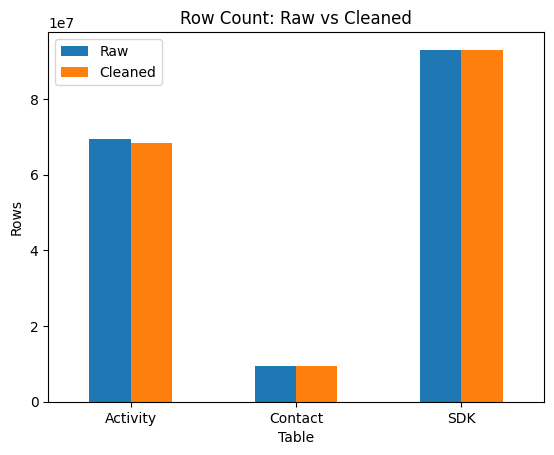

In [ ]:


df = pd.DataFrame({
    "Table": ["Activity", "Contact", "SDK"],
    "Raw": [
        con.execute("SELECT COUNT(*) FROM activity_clean").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM contact_clean").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM sdk_download_clean").fetchone()[0]
    ],
    "Cleaned": [
        con.execute("SELECT COUNT(*) FROM activity_final").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM contact_final").fetchone()[0],
        con.execute("SELECT COUNT(*) FROM sdk_download_final").fetchone()[0]
    ]
})

df.set_index("Table").plot(kind="bar")
plt.title("Row Count: Raw vs Cleaned")
plt.ylabel("Rows")
plt.xticks(rotation=0)
plt.show()

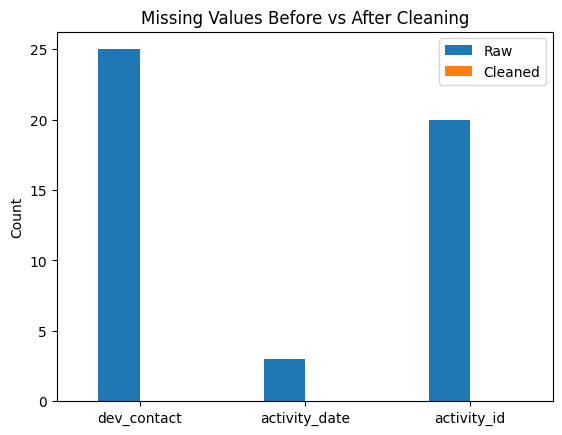

In [58]:
raw_nulls = con.execute("""
SELECT
    SUM(CASE WHEN dev_contact IS NULL THEN 1 ELSE 0 END) AS dev_contact,
    SUM(CASE WHEN activity_date IS NULL THEN 1 ELSE 0 END) AS activity_date,
    SUM(CASE WHEN activity_id IS NULL THEN 1 ELSE 0 END) AS activity_id
FROM activity_clean
""").fetchdf()

clean_nulls = con.execute("""
SELECT
    SUM(CASE WHEN dev_contact IS NULL THEN 1 ELSE 0 END) AS dev_contact,
    SUM(CASE WHEN activity_date IS NULL THEN 1 ELSE 0 END) AS activity_date,
    SUM(CASE WHEN activity_id IS NULL THEN 1 ELSE 0 END) AS activity_id
FROM activity_final
""").fetchdf()

df = pd.DataFrame({
    "Raw": raw_nulls.iloc[0],
    "Cleaned": clean_nulls.iloc[0]
})

df.plot(kind="bar")
plt.title("Missing Values Before vs After Cleaning")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

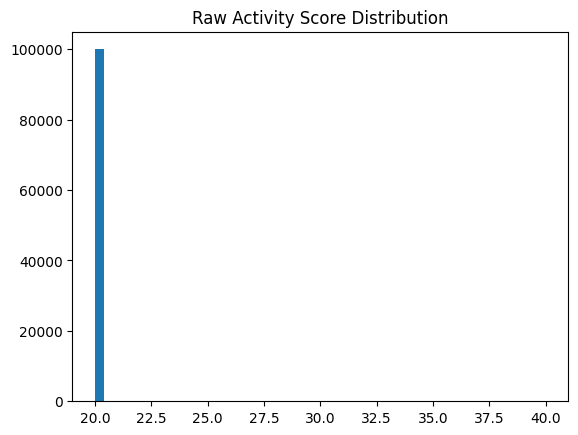

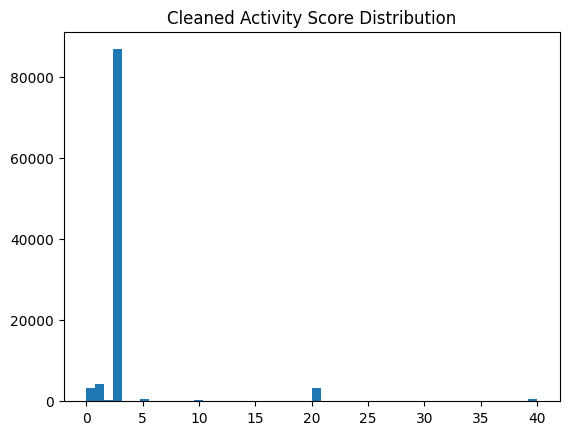

In [59]:
raw_scores = con.execute("""
SELECT activity_score
FROM activity_clean
WHERE activity_score IS NOT NULL
LIMIT 100000
""").fetchdf()

clean_scores = con.execute("""
SELECT activity_score
FROM activity_final
LIMIT 100000
""").fetchdf()

plt.hist(raw_scores["activity_score"], bins=50)
plt.title("Raw Activity Score Distribution")
plt.show()

plt.hist(clean_scores["activity_score"], bins=50)
plt.title("Cleaned Activity Score Distribution")
plt.show()

100% ▕██████████████████████████████████████▏ (00:00:06.77 elapsed)     
100% ▕██████████████████████████████████████▏ (00:00:05.60 elapsed)     


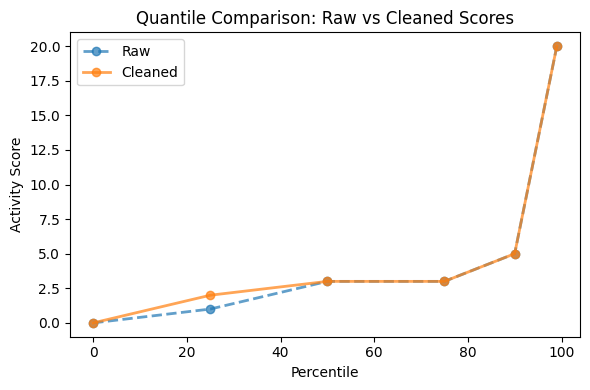

In [9]:
raw_q = con.execute("""
SELECT
    QUANTILE_CONT(CAST(activity_score AS DOUBLE), 0.0) AS p0,
    QUANTILE_CONT(CAST(activity_score AS DOUBLE), 0.25) AS p25,
    QUANTILE_CONT(CAST(activity_score AS DOUBLE), 0.50) AS p50,
    QUANTILE_CONT(CAST(activity_score AS DOUBLE), 0.75) AS p75,
    QUANTILE_CONT(CAST(activity_score AS DOUBLE), 0.90) AS p90,
    QUANTILE_CONT(CAST(activity_score AS DOUBLE), 0.99) AS p99
FROM activity_raw
WHERE activity_score IS NOT NULL
""").fetchdf()

clean_q = con.execute("""
SELECT
    QUANTILE_CONT(CAST(activity_score AS DOUBLE), 0.0) AS p0,
    QUANTILE_CONT(CAST(activity_score AS DOUBLE), 0.25) AS p25,
    QUANTILE_CONT(CAST(activity_score AS DOUBLE), 0.50) AS p50,
    QUANTILE_CONT(CAST(activity_score AS DOUBLE), 0.75) AS p75,
    QUANTILE_CONT(CAST(activity_score AS DOUBLE), 0.90) AS p90,
    QUANTILE_CONT(CAST(activity_score AS DOUBLE), 0.99) AS p99
FROM activity_final
WHERE activity_score IS NOT NULL
""").fetchdf()

percentiles = [0, 25, 50, 75, 90, 99]

plt.figure(figsize=(6,4))

plt.plot(
    percentiles,
    raw_q.values[0],
    marker='o',
    linestyle='--',
    alpha=0.7,
    linewidth=2,
    label="Raw"
)

plt.plot(
    percentiles,
    clean_q.values[0],
    marker='o',
    linestyle='-',
    alpha=0.7,
    linewidth=2,
    label="Cleaned"
)

plt.title("Quantile Comparison: Raw vs Cleaned Scores")
plt.xlabel("Percentile")
plt.ylabel("Activity Score")
plt.legend()
plt.tight_layout()
plt.show()

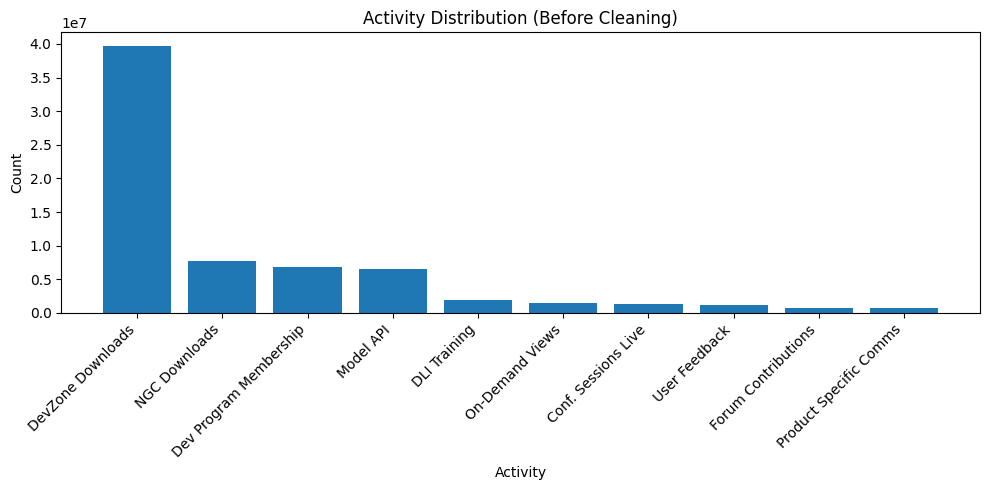

In [13]:
# BEFORE CLEANING
raw_cat = con.execute("""
SELECT
    activity AS activity_category,
    COUNT(*) AS cnt
FROM activity_clean
GROUP BY 1
ORDER BY cnt DESC
LIMIT 10
""").fetchdf()

plt.figure(figsize=(10,5))
plt.bar(raw_cat["activity_category"], raw_cat["cnt"])
plt.title("Activity Distribution (Before Cleaning)")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

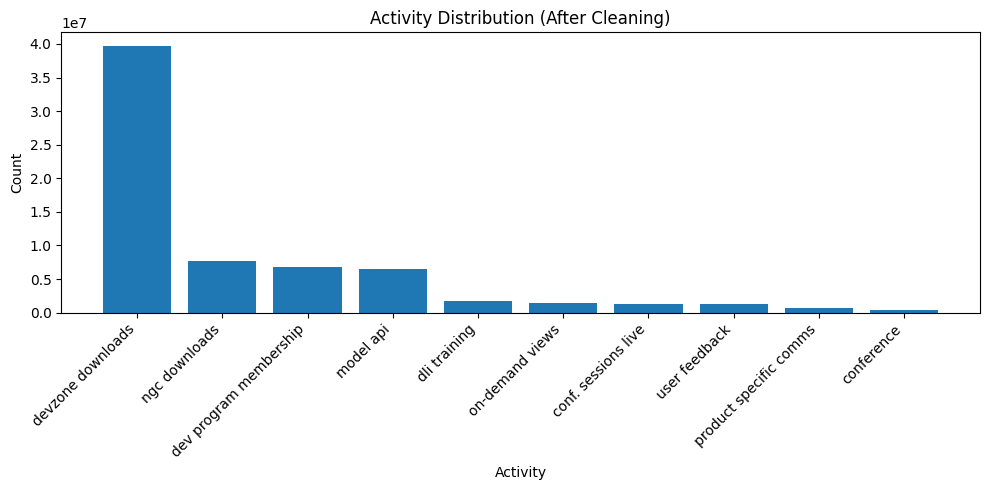

In [16]:
# AFTER CLEANING
clean_cat = con.execute("""
SELECT
    activity,
    COUNT(*) AS cnt
FROM activity_final
GROUP BY 1
ORDER BY cnt DESC
LIMIT 10
""").fetchdf()

plt.figure(figsize=(10,5))
plt.bar(clean_cat["activity"], clean_cat["cnt"])
plt.title("Activity Distribution (After Cleaning)")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

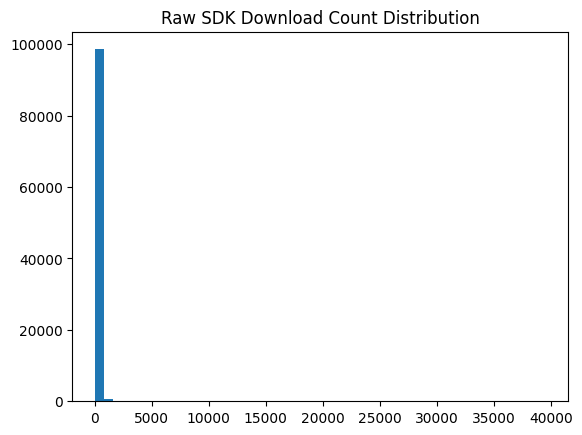

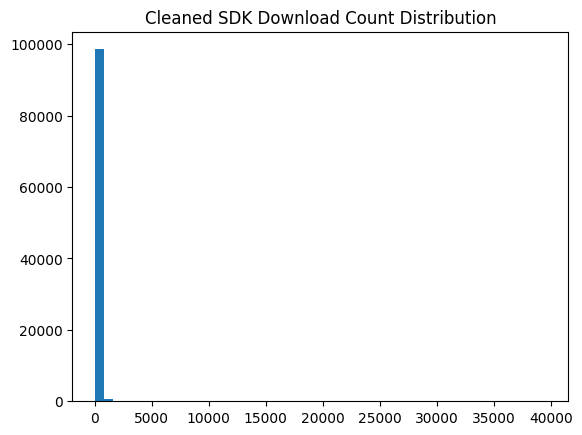

In [62]:
raw_sdk = con.execute("""
SELECT download_count
FROM sdk_download_clean
LIMIT 100000
""").fetchdf()

clean_sdk = con.execute("""
SELECT download_count
FROM sdk_download_final
LIMIT 100000
""").fetchdf()

plt.hist(raw_sdk["download_count"], bins=50)
plt.title("Raw SDK Download Count Distribution")
plt.show()

plt.hist(clean_sdk["download_count"], bins=50)
plt.title("Cleaned SDK Download Count Distribution")
plt.show()

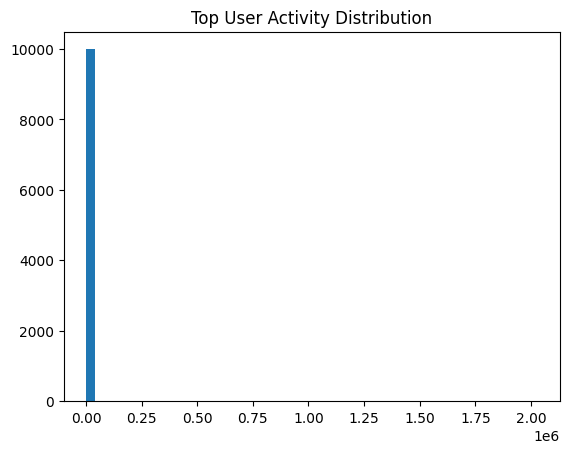

In [63]:
top_users = con.execute("""
SELECT total_activities_all_time
FROM developer_feature_base
ORDER BY total_activities_all_time DESC
LIMIT 10000
""").fetchdf()

plt.hist(top_users["total_activities_all_time"], bins=50)
plt.title("Top User Activity Distribution")
plt.show()

In [64]:
print(con.execute("""
SELECT
    'raw' AS dataset,
    COUNT(*) AS anomalies
FROM activity_clean
WHERE TRY_CAST(activity_score AS DOUBLE) < 0
   OR TRY_CAST(activity_score AS DOUBLE) > 100

UNION ALL

SELECT
    'cleaned' AS dataset,
    COUNT(*) AS anomalies
FROM activity_final
WHERE activity_score < 0 OR activity_score > 100
""").fetchdf())

   dataset  anomalies
0      raw          3
1  cleaned          0


In [65]:
con.close()

## Cleaning Summary

At this point, the project has produced cleaned versions of the three core datasets:

- `activity_final`
- `contact_final`
- `sdk_download_final`

These tables now provide the foundation for:

- joining activity with developer profiles
- building user-level behavioral features
- clustering developers into engagement cohorts
- evaluating how engagement may relate to adoption

## Where Rows Were Lost

Row reductions occurred at several stages during cleaning:

1. **Missing or Invalid Developer IDs**
   - Rows with null or empty `developer_id` or `dev_contact` were removed
   - These records cannot be reliably linked across datasets

2. **Duplicate Records**
   - Duplicate rows (based on developer or activity identifiers) were removed
   - This ensures each record represents a unique event or user

3. **Join Mismatches**
   - Some developers in the contacts dataset have no corresponding activity records
   - These users are retained in the final dataset (via LEFT JOIN), but their activity features are null or zero

4. **Activity Filtering (if applied)**
   - If any filtering was applied (e.g., removing invalid dates or scores), those rows were excluded

## Why Row Loss Is Expected

Row loss during cleaning is expected and necessary for data quality:

- Missing identifiers prevent reliable joins and must be removed
- Duplicate records can bias analysis and inflate metrics
- Real-world data often contains incomplete or inconsistent entries

Rather than forcing all data to be retained, we prioritize:
- accuracy
- consistency
- interpretability